# 1. Data & Feature Engineer (NLP Baseline)
### Sentiment Analysis Pipeline — Data Intake, Preprocessing & TF-IDF Feature Extraction
---
**Scope:** Dataset acquisition, text preprocessing pipeline, TF-IDF vectorization, and exploratory visualizations (class distribution + word cloud).

## Install & Import Libraries

In [1]:
# Uncomment if running for the first time
# !pip install nltk scikit-learn pandas numpy matplotlib seaborn wordcloud

import os
import re
import zipfile
import glob
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

import ssl

try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context


nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

warnings.filterwarnings('ignore')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Alivfff\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Alivfff\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Alivfff\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## 1. Dataset Acquisition & Loading

> **Instructions:**
> 1. Run the first cell to mount your Google Drive
> 2. Upload your ZIP file to your Google Drive (My Drive root is fine)
> 3. Update the  variable with your actual zip filename
> 4. Run the second cell — it will extract and load everything automatically

In [2]:
import zipfile
import os
import glob

# Paths & config (used by all cells below)
zip_path      = "archive.zip"
EXTRACT_DIR   = "./dataset/"
OUTPUT_CSV    = "sentiment_dataset.csv"

# Column name candidates — covers app review datasets (score, rating, etc.)
TEXT_COL_CANDIDATES  = ['review', 'text', 'content', 'comment', 'sentence', 'tweet', 'message']
LABEL_COL_CANDIDATES = ['score', 'rating', 'label', 'sentiment', 'class', 'polarity', 'stars']

os.makedirs(EXTRACT_DIR, exist_ok=True)

# Extract ZIP
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

files_found = os.listdir(EXTRACT_DIR)
print(f'   Files found ({len(files_found)}): {files_found[:10]}')

# Preview first CSV to confirm columns
import pandas as pd
first_csv = [f for f in files_found if f.endswith('.csv')]
if first_csv:
    sample = pd.read_csv(os.path.join(EXTRACT_DIR, first_csv[0]), nrows=3)
    print(f'\n📋 Sample columns from "{first_csv[0]}": {list(sample.columns)}')
    print(sample)

   Files found (21): ['all_combined.csv', 'Candy Crush Saga.csv', 'Dropbox.csv', 'Facebook Lite.csv', 'Facebook Messenger.csv', 'Facebook.csv', 'Flipboard.csv', 'Instagram.csv', 'LINE.csv', 'Microsoft PowerPoint.csv']

📋 Sample columns from "all_combined.csv": ['reviewId', 'content', 'score', 'app']
                               reviewId  \
0  1259786c-13cc-48b5-9bed-a5e8e21f410d   
1  bcd54507-bb4a-4a52-a9f7-4e78eb69a9e3   
2  83be76c0-1392-470c-8ad3-aa6424d6ae48   

                                   content  score       app  
0                       nice platform ♥️♥️      5  Facebook  
1  por favor dejame oculta sesion de reels      1  Facebook  
2                        অনেক অনেক ধন্যবাদ      5  Facebook  


In [3]:
def detect_columns(df):
    """Auto-detect text and label columns by common names."""
    cols = [c.lower().strip() for c in df.columns]
    df.columns = cols

    text_col  = next((c for c in TEXT_COL_CANDIDATES if c in cols), None)
    label_col = next((c for c in LABEL_COL_CANDIDATES if c in cols), None)

    if text_col is None or label_col is None:
        print(f'  Could not auto-detect columns. Found: {list(df.columns)}')
        print('   Using first two columns as [text, label].')
        text_col  = text_col  or df.columns[0]
        label_col = label_col or df.columns[1]

    return text_col, label_col


def load_files_from_dir(directory):
    """Load all CSV and TXT files from a directory recursively."""
    all_frames = []

    for filepath in glob.glob(os.path.join(directory, '**', '*.csv'), recursive=True):
        try:
            df = pd.read_csv(filepath, encoding='utf-8', on_bad_lines='skip')
        except UnicodeDecodeError:
            df = pd.read_csv(filepath, encoding='latin-1', on_bad_lines='skip')
        text_col, label_col = detect_columns(df)
        frame = df[[text_col, label_col]].rename(columns={text_col: 'text', label_col: 'label'})
        frame['source_file'] = os.path.basename(filepath)
        all_frames.append(frame)
        print(f'  Loaded: {os.path.basename(filepath)}  → {len(frame)} rows')

    for filepath in glob.glob(os.path.join(directory, '**', '*.txt'), recursive=True):
        rows = []
        with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                if '\t' in line:
                    parts = line.split('\t', 1)
                    rows.append({'label': parts[0].strip(), 'text': parts[1].strip()})
                else:
                    rows.append({'text': line, 'label': 'unknown'})
        if rows:
            frame = pd.DataFrame(rows)
            frame['source_file'] = os.path.basename(filepath)
            all_frames.append(frame)
            print(f'  Loaded TXT: {os.path.basename(filepath)}  → {len(frame)} rows')

    if not all_frames:
        raise ValueError('No CSV or TXT files found inside the ZIP.')

    combined = pd.concat(all_frames, ignore_index=True)
    return combined


print('🔍 Scanning and loading files...')
df_raw = load_files_from_dir(EXTRACT_DIR)
print(f'\nRaw dataset shape: {df_raw.shape}')
print(f'   Raw label sample: {df_raw["label"].value_counts().head(10).to_dict()}')


🔍 Scanning and loading files...
  Loaded: all_combined.csv  → 200000 rows
  Loaded: Candy Crush Saga.csv  → 10000 rows
  Loaded: Dropbox.csv  → 10000 rows
  Loaded: Facebook Lite.csv  → 10000 rows
  Loaded: Facebook Messenger.csv  → 10000 rows
  Loaded: Facebook.csv  → 10000 rows
  Loaded: Flipboard.csv  → 10000 rows
  Loaded: Instagram.csv  → 10000 rows
  Loaded: LINE.csv  → 10000 rows
  Loaded: Microsoft PowerPoint.csv  → 10000 rows
  Loaded: Microsoft Word.csv  → 10000 rows
  Loaded: Netflix.csv  → 10000 rows
  Loaded: SHAREit.csv  → 10000 rows
  Loaded: Skype.csv  → 10000 rows
  Loaded: Snapchat.csv  → 10000 rows
  Loaded: Spotify.csv  → 10000 rows
  Loaded: Subway Surfers.csv  → 10000 rows
  Loaded: TikTok.csv  → 10000 rows
  Loaded: Twitter.csv  → 10000 rows
  Loaded: Viber.csv  → 10000 rows
  Loaded: WhatsApp.csv  → 10000 rows

Raw dataset shape: (400000, 3)
   Raw label sample: {5: 242230, 1: 87760, 4: 33368, 3: 19952, 2: 16690}


In [4]:
# Normalise label values
# Handles: text labels, numeric ratings (1–5 stars), binary (0/1)
def normalise_labels(label):
    label = str(label).lower().strip()

    # Star ratings (1–5): 4–5 = positive, 3 = neutral, 1–2 = negative
    if label in ['5', '4']:
        return 'positive'
    if label in ['3']:
        return 'neutral'
    if label in ['1', '2']:
        return 'negative'

    # Text labels
    if label in ['positive', 'pos', 'good', 'like']:
        return 'positive'
    if label in ['negative', 'neg', 'bad', 'dislike']:
        return 'negative'
    if label in ['neutral', 'neu', 'neither']:
        return 'neutral'

    return label  # keep as-is if unrecognised


df_raw['label'] = df_raw['label'].apply(normalise_labels)

# Drop rows missing text or label
df_raw.dropna(subset=['text', 'label'], inplace=True)
df_raw = df_raw[df_raw['text'].str.strip() != '']
df_raw.reset_index(drop=True, inplace=True)

print(f'   After label normalisation: {df_raw.shape[0]} rows')
print(f'   Labels: {df_raw["label"].value_counts().to_dict()}')
df_raw.head()


   After label normalisation: 399964 rows
   Labels: {'positive': 275572, 'negative': 104442, 'neutral': 19950}


,text,label,source_file
0,nice platform ♥️♥️,positive,all_combined.csv
1,por favor dejame oculta sesion de reels,negative,all_combined.csv
2,অনেক অনেক ধন্যবাদ,positive,all_combined.csv
3,sus you,neutral,all_combined.csv
4,great app! no frills just thrill! 😍,positive,all_combined.csv


In [5]:
# Save the raw merged CSV
df_raw[['text', 'label']].to_csv(OUTPUT_CSV, index=False)

---
## 2. Text Preprocessing Pipeline

The pipeline applies these steps in order:
1. Lowercase conversion
2. Remove URLs, mentions, hashtags
3. Remove special characters and numbers
4. Tokenisation
5. Stopword removal
6. Lemmatisation (preferred) with optional stemming fallback

In [6]:
STOP_WORDS  = set(stopwords.words('english'))
lemmatizer  = WordNetLemmatizer()
stemmer     = PorterStemmer()

# Keep negation words — they matter for sentiment
NEGATION_WORDS = {'no', 'not', "n't", 'never', 'neither', 'nor', 'nobody', 'nothing', 'nowhere'}
STOP_WORDS -= NEGATION_WORDS


def preprocess_text(text, use_stemming=False):
    """
    Full text preprocessing pipeline.

    Parameters
    ----------
    text         : str  — raw input text
    use_stemming : bool — apply PorterStemmer instead of lemmatisation

    Returns
    -------
    str — clean, space-joined token string
    """
    # Step 1 — Lowercase
    text = str(text).lower()

    # Step 2 — Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # Step 3 — Remove @mentions and #hashtags
    text = re.sub(r'@\w+|#\w+', '', text)

    # Step 4 — Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Step 5 — Expand common contractions
    contractions = {
        "n't": " not", "'re": " are", "'s": " is",
        "'d": " would", "'ll": " will", "'ve": " have", "'m": " am"
    }
    for k, v in contractions.items():
        text = text.replace(k, v)

    # Step 6 — Remove special characters and numbers (keep letters and spaces)
    text = re.sub(r'[^a-z\s]', '', text)

    # Step 7 — Tokenise
    tokens = word_tokenize(text)

    # Step 8 — Remove stopwords and short tokens
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 2]

    # Step 9 — Lemmatise or stem
    if use_stemming:
        tokens = [stemmer.stem(t) for t in tokens]
    else:
        tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return ' '.join(tokens)


# Smoke test
sample = "I didn't love this product at all! It's absolutely terrible. Visit http://spam.com for more info."
print('Original :', sample)
print('Processed:', preprocess_text(sample))


Original : I didn't love this product at all! It's absolutely terrible. Visit http://spam.com for more info.
Processed: not love product absolutely terrible visit info


In [7]:
df = df_raw[['text', 'label']].copy()
df['text_clean'] = df['text'].apply(preprocess_text)

# Drop rows that became empty after cleaning
df = df[df['text_clean'].str.strip() != '']
df.reset_index(drop=True, inplace=True)

# Token count stats
df['token_count_raw']   = df['text'].apply(lambda x: len(str(x).split()))
df['token_count_clean'] = df['text_clean'].apply(lambda x: len(x.split()))

print(f'Preprocessing complete!  {len(df)} samples remaining.')
print(f'\n   Avg tokens before cleaning: {df["token_count_raw"].mean():.1f}')
print(f'   Avg tokens after  cleaning: {df["token_count_clean"].mean():.1f}')
df.head()


Preprocessing complete!  379628 samples remaining.

   Avg tokens before cleaning: 11.1
   Avg tokens after  cleaning: 6.1


,text,label,text_clean,token_count_raw,token_count_clean
0,nice platform ♥️♥️,positive,nice platform,3,2
1,por favor dejame oculta sesion de reels,negative,por favor dejame oculta sesion reel,7,6
2,sus you,neutral,sus,2,1
3,great app! no frills just thrill! 😍,positive,great app frill thrill,7,4
4,good,positive,good,1,1


In [8]:
# Save cleaned dataset
CLEANED_CSV = 'sentiment_dataset_cleaned.csv'
df[['text', 'label', 'text_clean']].to_csv(CLEANED_CSV, index=False)

---
## 3. Exploratory Visualizations
### 3.1 Class Distribution

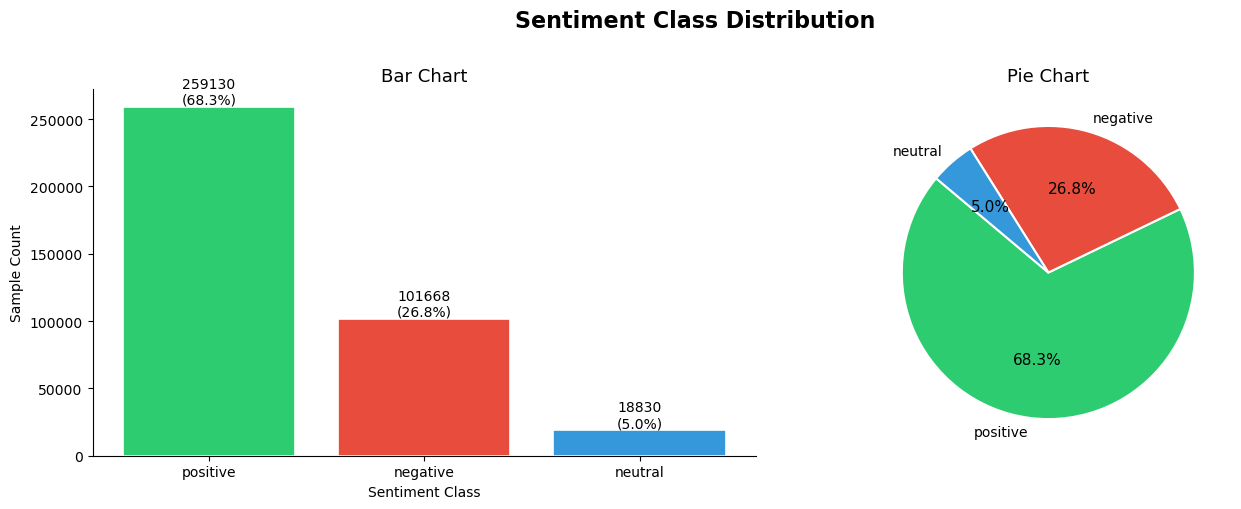

In [9]:
os.makedirs('./visualizations', exist_ok=True)

label_counts = df['label'].value_counts()
PALETTE = {'positive': '#2ecc71', 'negative': '#e74c3c', 'neutral': '#3498db'}
colors   = [PALETTE.get(l, '#95a5a6') for l in label_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Sentiment Class Distribution', fontsize=16, fontweight='bold', y=1.01)

# Bar chart
bars = axes[0].bar(label_counts.index, label_counts.values, color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('Bar Chart', fontsize=13)
axes[0].set_xlabel('Sentiment Class')
axes[0].set_ylabel('Sample Count')
axes[0].spines[['top', 'right']].set_visible(False)
for bar, val in zip(bars, label_counts.values):
    pct = val / len(df) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{val}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    label_counts.values, labels=label_counts.index,
    colors=colors, autopct='%1.1f%%', startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
for at in autotexts:
    at.set_fontsize(11)
axes[1].set_title('Pie Chart', fontsize=13)

plt.tight_layout()
plt.savefig('./visualizations/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.2 Word Cloud — Overall Cleaned Corpus

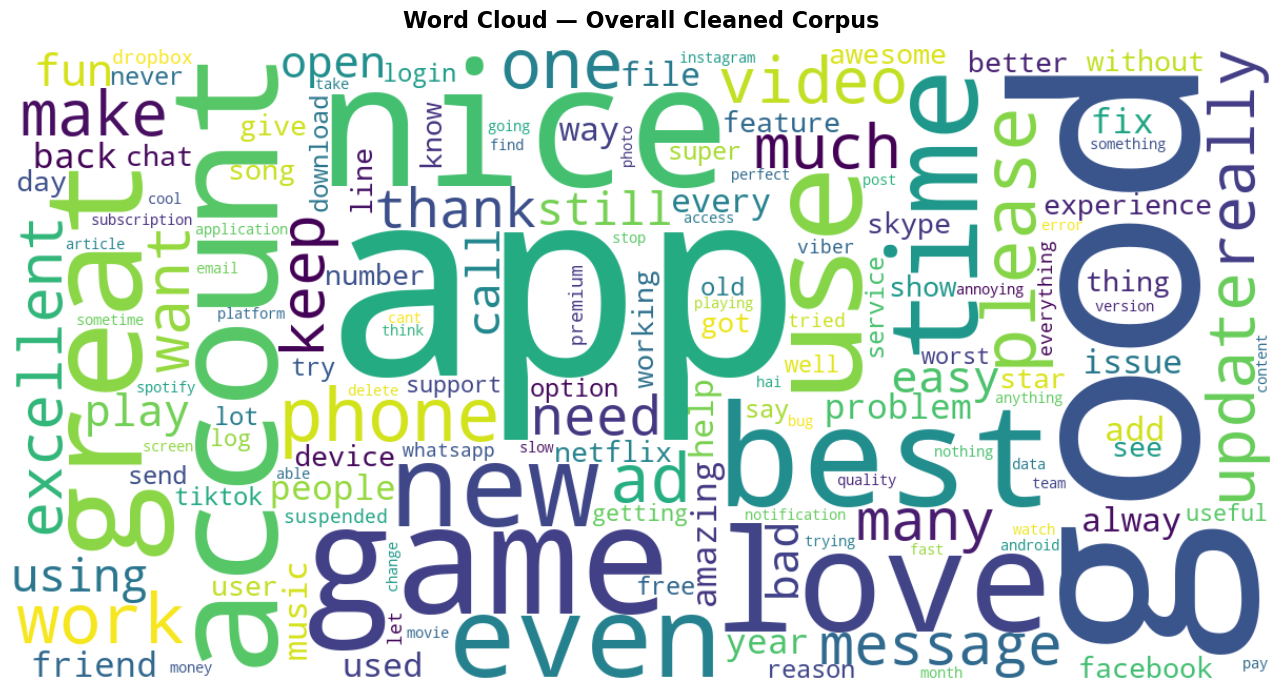

In [10]:
all_text = ' '.join(df['text_clean'].dropna().tolist())

wordcloud = WordCloud(
    width=1200, height=600,
    background_color='white',
    colormap='viridis',
    max_words=150,
    collocations=False
).generate(all_text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — Overall Cleaned Corpus', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('./visualizations/wordcloud_overall.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.3 Per-Class Word Clouds

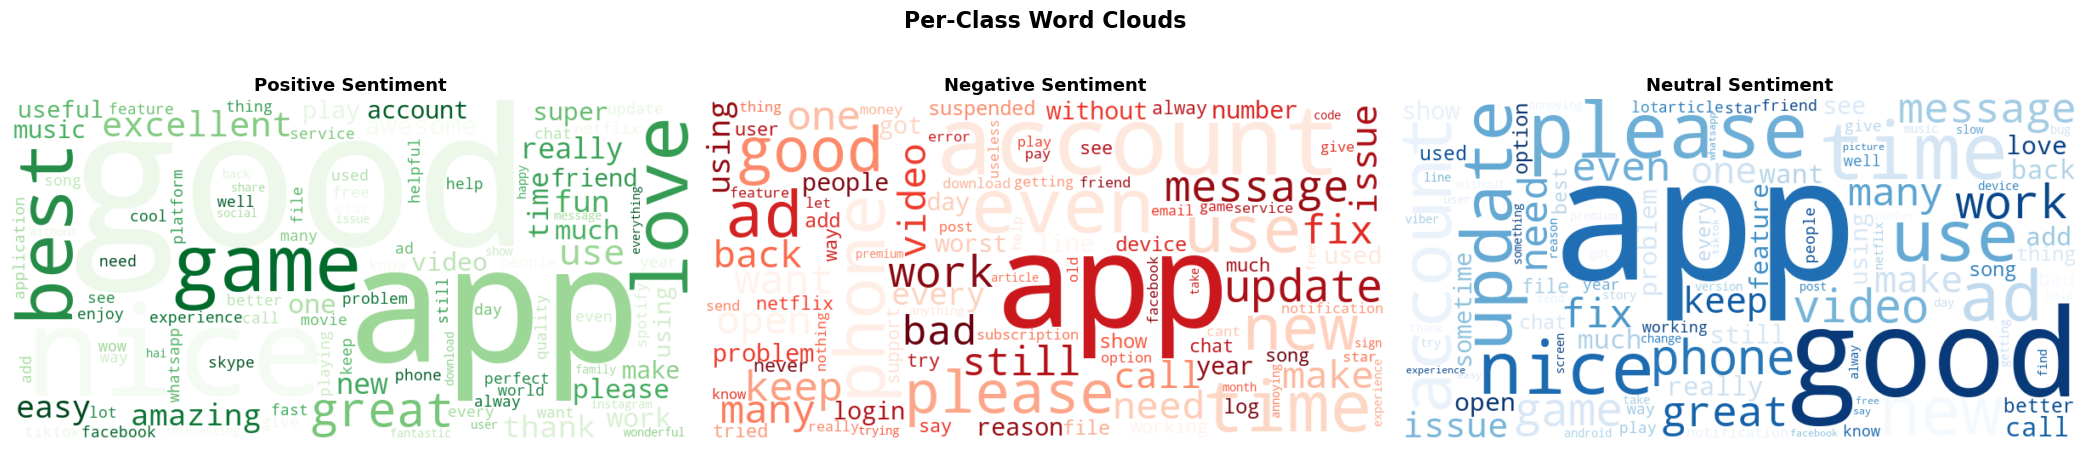

In [11]:
class_cmaps = {'positive': 'Greens', 'negative': 'Reds', 'neutral': 'Blues'}
unique_labels = df['label'].unique()

fig, axes = plt.subplots(1, len(unique_labels), figsize=(7 * len(unique_labels), 5))
if len(unique_labels) == 1:
    axes = [axes]

for ax, label in zip(axes, unique_labels):
    subset_text = ' '.join(df[df['label'] == label]['text_clean'].dropna().tolist())
    if not subset_text.strip():
        ax.set_title(f'{label.capitalize()} — no data')
        continue
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        colormap=class_cmaps.get(label, 'Purples'),
        max_words=100,
        collocations=False
    ).generate(subset_text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{label.capitalize()} Sentiment', fontsize=13, fontweight='bold')

fig.suptitle('Per-Class Word Clouds', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('./visualizations/wordclouds_per_class.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.4 Top 20 Most Frequent Words

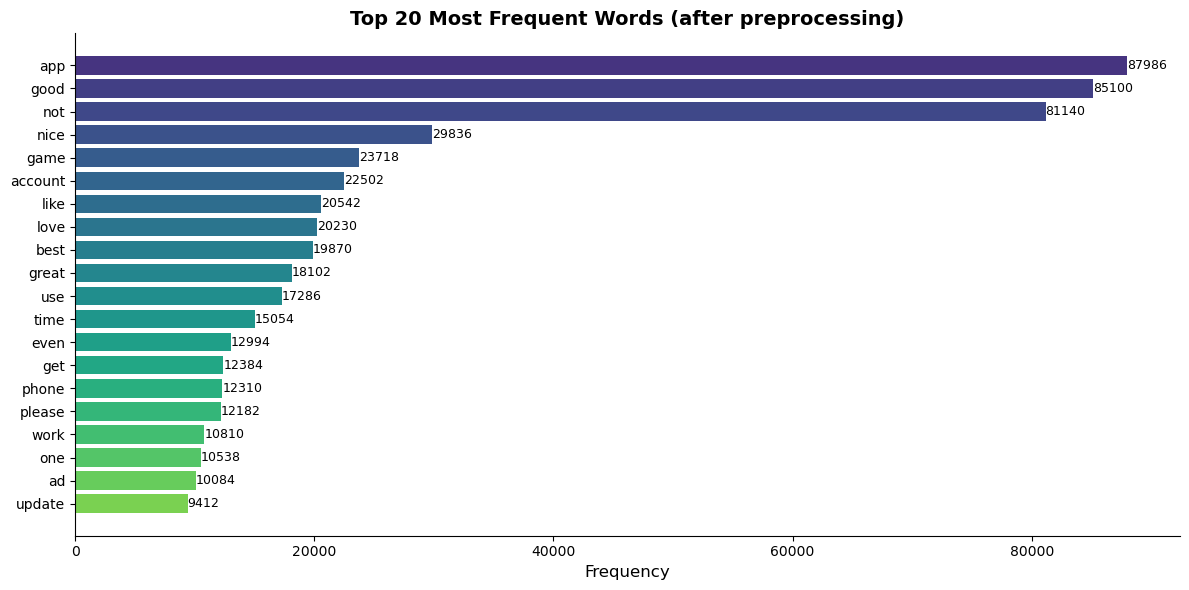

In [12]:
all_tokens = ' '.join(df['text_clean']).split()
top_20 = Counter(all_tokens).most_common(20)
words, freqs = zip(*top_20)

plt.figure(figsize=(12, 6))
bars = plt.barh(words[::-1], freqs[::-1],
                color=plt.cm.viridis_r(np.linspace(0.2, 0.85, 20)))
plt.xlabel('Frequency', fontsize=12)
plt.title('Top 20 Most Frequent Words (after preprocessing)', fontsize=14, fontweight='bold')
plt.gca().spines[['top', 'right']].set_visible(False)
for bar, freq in zip(bars, freqs[::-1]):
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             str(freq), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('./visualizations/top20_words.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.5 Text Length Distribution (before vs after preprocessing)

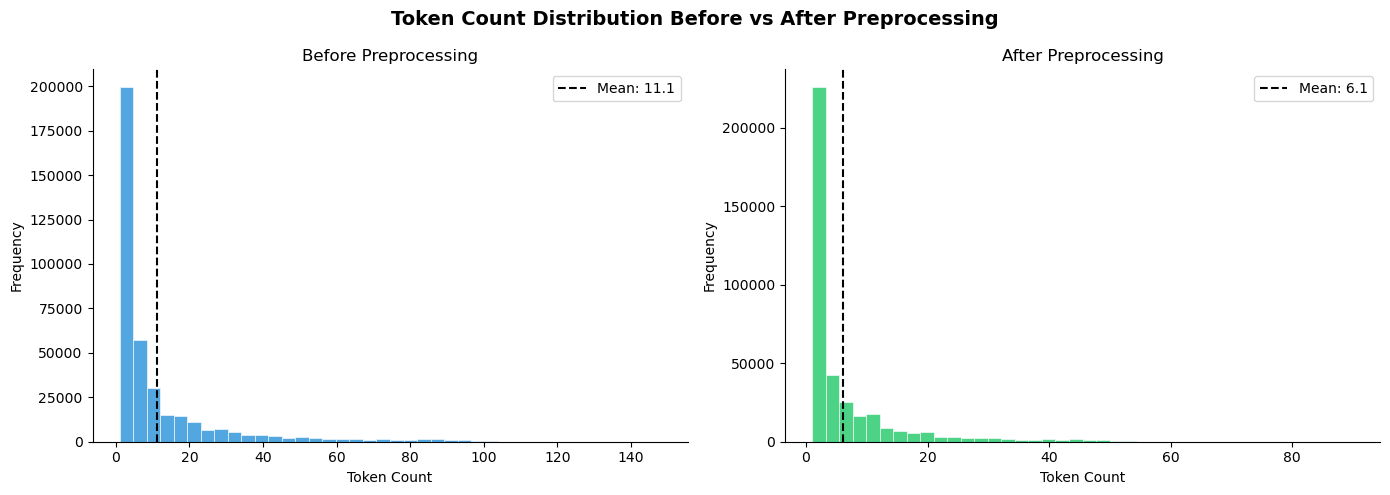

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Token Count Distribution Before vs After Preprocessing', fontsize=14, fontweight='bold')

for ax, col, title, color in zip(
    axes,
    ['token_count_raw', 'token_count_clean'],
    ['Before Preprocessing', 'After Preprocessing'],
    ['#3498db', '#2ecc71']
):
    ax.hist(df[col], bins=40, color=color, edgecolor='white', linewidth=0.5, alpha=0.85)
    ax.axvline(df[col].mean(), color='black', linestyle='--', linewidth=1.5,
               label=f'Mean: {df[col].mean():.1f}')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Token Count')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('./visualizations/token_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 4. Feature Extraction — TF-IDF Vectorization (Method 1)

TF-IDF (Term Frequency – Inverse Document Frequency) converts text into a numeric matrix. Each cell represents how important a word is to a document relative to the entire corpus.

In [14]:
# Train / Test split
X = df['text_clean']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {len(X_train)} samples | Test: {len(X_test)} samples')


Train: 303702 samples | Test: 75926 samples


In [15]:
# Fit TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,       # top 5000 terms
    ngram_range=(1, 2),      # unigrams + bigrams
    min_df=2,                # ignore terms that appear in fewer than 2 docs
    max_df=0.95,             # ignore terms in more than 95% of docs
    sublinear_tf=True        # apply log normalization to TF
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)

print(f'   Vocabulary size : {len(tfidf_vectorizer.vocabulary_):,}')
print(f'   Train matrix    : {X_train_tfidf.shape}  (rows=samples, cols=features)')
print(f'   Test  matrix    : {X_test_tfidf.shape}')
print(f'   Matrix density  : {X_train_tfidf.nnz / (X_train_tfidf.shape[0]*X_train_tfidf.shape[1])*100:.2f}% non-zero')


   Vocabulary size : 5,000
   Train matrix    : (303702, 5000)  (rows=samples, cols=features)
   Test  matrix    : (75926, 5000)
   Matrix density  : 0.12% non-zero


In [16]:
# Top TF-IDF terms per class
feature_names = tfidf_vectorizer.get_feature_names_out()

print('Top 15 TF-IDF terms per sentiment class:\n')
for label in df['label'].unique():
    indices = df[df['label'] == label].index
    class_X = tfidf_vectorizer.transform(df.loc[indices, 'text_clean'])
    mean_scores = class_X.mean(axis=0).A1
    top_idx = mean_scores.argsort()[::-1][:15]
    top_terms = [(feature_names[i], round(mean_scores[i], 4)) for i in top_idx]
    print(f'  [{label.upper()}]')
    for term, score in top_terms:
        print(f'    {term:<25} {score}')
    print()


Top 15 TF-IDF terms per sentiment class:

  [POSITIVE]
    good                      0.1918
    nice                      0.0731
    app                       0.0445
    best                      0.0317
    great                     0.031
    love                      0.031
    excellent                 0.0236
    game                      0.0228
    good app                  0.0183
    like                      0.0152
    amazing                   0.0131
    awesome                   0.0126
    nice app                  0.011
    super                     0.0103
    fun                       0.01

  [NEGATIVE]
    not                       0.0604
    app                       0.0366
    good                      0.0258
    account                   0.0223
    bad                       0.0187
    ad                        0.0149
    even                      0.0142
    time                      0.0126
    phone                     0.0125
    get                       0.0114
    update 

### 4.1 TF-IDF Heatmap — Sample Preview

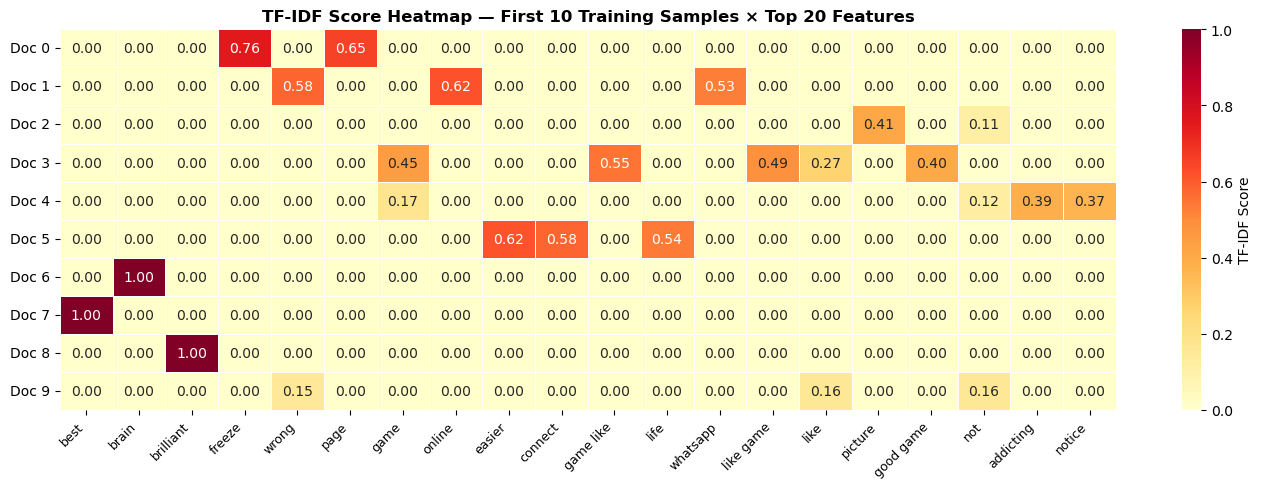

In [17]:
# Show top-20 features for first 10 training samples as a heatmap
sample_matrix = X_train_tfidf[:10, :]
mean_scores   = sample_matrix.mean(axis=0).A1
top20_idx     = mean_scores.argsort()[::-1][:20]

heatmap_data = pd.DataFrame(
    sample_matrix[:, top20_idx].toarray(),
    columns=feature_names[top20_idx],
    index=[f'Doc {i}' for i in range(10)]
)

plt.figure(figsize=(14, 5))
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'TF-IDF Score'})
plt.title('TF-IDF Score Heatmap — First 10 Training Samples × Top 20 Features',
          fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('./visualizations/tfidf_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Feature Extraction — Word2Vec Vectorization

In [18]:
!pip install gensim

In [19]:
# Install & train Word2Vec

from gensim.models import Word2Vec
import numpy as np

# Tokenise cleaned text into list of word lists
tokenized_corpus = [text.split() for text in df['text_clean']]

# Train Word2Vec model
w2v_model = Word2Vec(
    sentences=tokenized_corpus,
    vector_size=100,    # embedding dimensions
    window=5,           # context window size
    min_count=2,        # ignore words appearing < 2 times
    workers=4,
    epochs=10,
    seed=42
)

print(f'   Vocabulary size : {len(w2v_model.wv):,} words')
print(f'   Vector size     : {w2v_model.vector_size} dimensions')

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


   Vocabulary size : 48,958 words
   Vector size     : 100 dimensions


In [20]:
# Convert texts to vectors
def text_to_w2v_vector(text, model):
    """Average all word vectors in a text to get one fixed-size vector."""
    tokens = text.split()
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if not vectors:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

# Generate feature matrices
X_train_w2v = np.array([text_to_w2v_vector(t, w2v_model) for t in X_train])
X_test_w2v  = np.array([text_to_w2v_vector(t, w2v_model) for t in X_test])

print(f'   Train matrix : {X_train_w2v.shape}')
print(f'   Test  matrix : {X_test_w2v.shape}')

   Train matrix : (303702, 100)
   Test  matrix : (75926, 100)


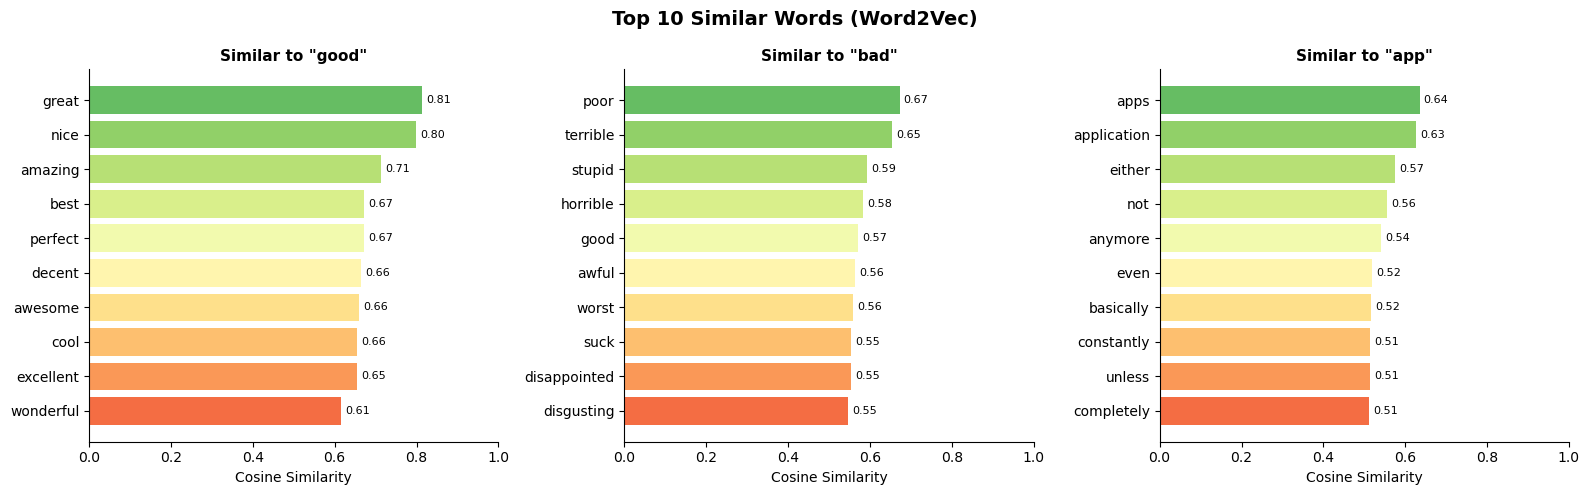

In [21]:
# ── Word Similarity Bar Chart ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Top 10 Similar Words (Word2Vec)', fontsize=14, fontweight='bold')

target_words = ['good', 'bad', 'app']  # ganti sesuai dataset kamu

for ax, word in zip(axes, target_words):
    if word not in w2v_model.wv:
        ax.set_title(f'"{word}" not in vocab')
        ax.axis('off')
        continue

    similar = w2v_model.wv.most_similar(word, topn=10)
    words_sim, scores = zip(*similar)

    bars = ax.barh(words_sim[::-1], scores[::-1],
                   color=plt.cm.RdYlGn(np.linspace(0.2, 0.8, 10)))
    ax.set_title(f'Similar to "{word}"', fontsize=11, fontweight='bold')
    ax.set_xlabel('Cosine Similarity')
    ax.set_xlim(0, 1)
    ax.spines[['top', 'right']].set_visible(False)
    for bar, score in zip(bars, scores[::-1]):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f'{score:.2f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('./visualizations/w2v_similarity.png', dpi=150, bbox_inches='tight')
plt.show()

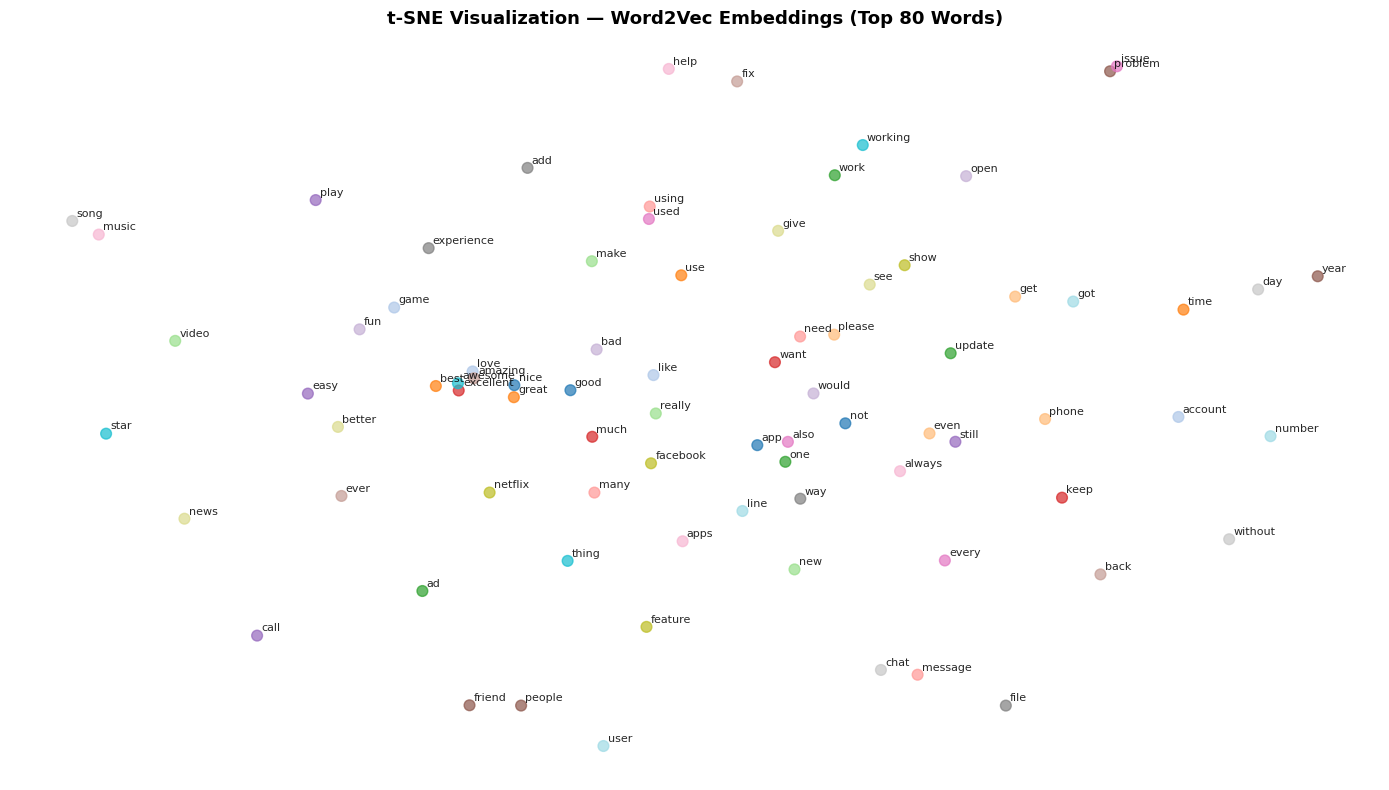

In [22]:
# ── t-SNE Word Embeddings Visualization ──────────────────────
from sklearn.manifold import TSNE

# Ambil top 100 kata paling sering muncul di corpus
all_tokens = [word for text in tokenized_corpus for word in text]
top_words = [word for word, _ in Counter(all_tokens).most_common(100)
             if word in w2v_model.wv][:80]

# Ambil vector tiap kata
vectors = np.array([w2v_model.wv[word] for word in top_words])

# Reduksi dimensi ke 2D pakai t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
vectors_2d = tsne.fit_transform(vectors)

# Plot
plt.figure(figsize=(14, 8))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1],
            c=range(len(top_words)), cmap='tab20', alpha=0.7, s=60)

for i, word in enumerate(top_words):
    plt.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]),
                 fontsize=8, alpha=0.85,
                 xytext=(3, 3), textcoords='offset points')

plt.title('t-SNE Visualization — Word2Vec Embeddings (Top 80 Words)',
          fontsize=13, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.savefig('./visualizations/w2v_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

# 2. Model Training

In [23]:
# ─────────────────────────────────────────────
# SECTION 1 │ IMPORTS & SETUP
# ─────────────────────────────────────────────

import matplotlib.ticker as mticker
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

# Class labels – adjust if your encoder uses different names
CLASS_NAMES   = ['Negative', 'Neutral', 'Positive']
N_CLASSES     = len(CLASS_NAMES)

# Output directory for saved artefacts
os.makedirs('models', exist_ok=True)

print("✅  All imports successful.")


✅  All imports successful.


In [24]:
# Oversampling using SMOTE

from imblearn.over_sampling import SMOTE
import numpy as np

# Initialize SMOTE
smote = SMOTE(random_state=42)

# 1. Apply SMOTE to the TF-IDF Training Data (Expect this to take time/RAM)
print("Applying SMOTE to TF-IDF Training Data...")
X_train_tfidf_sm, y_train_tfidf_sm = smote.fit_resample(X_train_tfidf, y_train)
print(f"Original TF-IDF shape: {X_train_tfidf.shape}, SMOTE TF-IDF shape: {X_train_tfidf_sm.shape}")

# 2. Apply SMOTE to the Word2Vec Training Data
print("\nApplying SMOTE to Word2Vec Training Data...")
X_train_w2v_sm, y_train_w2v_sm = smote.fit_resample(X_train_w2v, y_train)
print(f"Original Word2Vec shape: {X_train_w2v.shape}, SMOTE Word2Vec shape: {X_train_w2v_sm.shape}")

Applying SMOTE to TF-IDF Training Data...
Original TF-IDF shape: (303702, 5000), SMOTE TF-IDF shape: (621912, 5000)

Applying SMOTE to Word2Vec Training Data...
Original Word2Vec shape: (303702, 100), SMOTE Word2Vec shape: (621912, 100)


In [25]:
from sklearn.model_selection import GridSearchCV

# Define a tight, computationally safe hyperparameter grid
param_grid = {'C': [0.01, 0.1, 0.5, 1.0, 5.0]}

print("\n" + "="*60)
print("  MODEL 1 │ LOGISTIC REGRESSION (OPTIMIZED WITH GRID SEARCH)")
print("="*60)

# ── Config A: Logistic Regression × TF-IDF ────────────────────────────────
print("\n[Config A] Logistic Regression × TF-IDF (Grid Search on SMOTE)")
grid_lr_tfidf = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, solver='lbfgs', multi_class='multinomial', random_state=42, n_jobs=-1), 
    param_grid=param_grid, 
    cv=3, 
    scoring='f1_macro', 
    n_jobs=-1
)

# Fit Grid Search on SMOTE TF-IDF data
grid_lr_tfidf.fit(X_train_tfidf_sm, y_train_tfidf_sm)
print(f"   Best C: {grid_lr_tfidf.best_params_['C']} (Training F1-Macro: {grid_lr_tfidf.best_score_:.4f})")

# Extract the best model and evaluate on test data
best_lr_tfidf = grid_lr_tfidf.best_estimator_
y_pred_lr_tfidf  = best_lr_tfidf.predict(X_test_tfidf)
y_proba_lr_tfidf = best_lr_tfidf.predict_proba(X_test_tfidf)

print(f"   Test Accuracy : {accuracy_score(y_test, y_pred_lr_tfidf):.4f}")
print(f"   Test F1-macro : {f1_score(y_test, y_pred_lr_tfidf, average='macro'):.4f}")
print("\n   Classification Report:")
print(classification_report(y_test, y_pred_lr_tfidf, target_names=CLASS_NAMES))


# ── Config B: Logistic Regression × Word2Vec ────────────────────────────────
print("\n[Config B] Logistic Regression × Word2Vec (Grid Search on SMOTE)")
grid_lr_w2v = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, solver='lbfgs', multi_class='multinomial', random_state=42, n_jobs=-1), 
    param_grid=param_grid, 
    cv=3, 
    scoring='f1_macro', 
    n_jobs=-1
)

# Fit Grid Search on SMOTE Word2Vec data
grid_lr_w2v.fit(X_train_w2v_sm, y_train_w2v_sm)
print(f"   Best C: {grid_lr_w2v.best_params_['C']} (Training F1-Macro: {grid_lr_w2v.best_score_:.4f})")

# Extract the best model and evaluate
best_lr_w2v = grid_lr_w2v.best_estimator_
y_pred_lr_w2v  = best_lr_w2v.predict(X_test_w2v)
y_proba_lr_w2v = best_lr_w2v.predict_proba(X_test_w2v)

print(f"   Test Accuracy : {accuracy_score(y_test, y_pred_lr_w2v):.4f}")
print(f"   Test F1-macro : {f1_score(y_test, y_pred_lr_w2v, average='macro'):.4f}")
print("\n   Classification Report:")
print(classification_report(y_test, y_pred_lr_w2v, target_names=CLASS_NAMES))


print("\n" + "="*60)
print("  MODEL 2 │ DISTILBERT FINE-TUNING (CPU-OPTIMISED)")
print("="*60)

# ── Install dependencies ───────────────────────────────────────────────────
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                       "transformers", "torch", "datasets"])

import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from torch.optim import AdamW
from sklearn.preprocessing import LabelEncoder

print("\n[Config C] DistilBERT × Raw Text (Fine-tuned, CPU)")

# ── Hyperparameters (tune these for your dataset size) ────────────────────
BERT_MODEL_NAME = "distilbert-base-uncased"
BERT_MAX_LEN    = 256      # max token length — 128 is fast on CPU, 256 is richer
BERT_BATCH_SIZE = 16       # keep at 16 for CPU; lower to 8 if RAM is tight
BERT_EPOCHS     = 2        # 3 epochs is standard; reduce to 2 if slow
BERT_LR         = 2e-5     # standard fine-tuning LR
BERT_WARMUP     = 0.1      # fraction of steps used for LR warmup

# ── Label encoding ────────────────────────────────────────────────────────
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc  = label_encoder.transform(y_test)
BERT_CLASSES = label_encoder.classes_.tolist()   # e.g. ['negative', 'neutral', 'positive']
NUM_LABELS   = len(BERT_CLASSES)

print(f"   Label mapping : {dict(enumerate(BERT_CLASSES))}")
print(f"   Train samples : {len(y_train_enc)} | Test samples : {len(y_test_enc)}")


# ── Dataset class ─────────────────────────────────────────────────────────
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            padding='max_length',
            max_length=max_len,
            return_tensors='pt'
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item


# ── Load tokenizer & model ────────────────────────────────────────────────
print("\n   Loading DistilBERT tokenizer & model...")
tokenizer_bert = DistilBertTokenizerFast.from_pretrained(BERT_MODEL_NAME)
bert_model     = DistilBertForSequenceClassification.from_pretrained(
    BERT_MODEL_NAME, num_labels=NUM_LABELS
)
bert_model.eval()  # will switch to train() below

device = torch.device("cpu")
bert_model.to(device)
print(f"   Model loaded. Device: {device}")

# ── Build DataLoaders ─────────────────────────────────────────────────────
# Use X_train / X_test (raw text, NOT text_clean) — BERT handles tokenisation
train_dataset = SentimentDataset(X_train.values, y_train_enc, tokenizer_bert, BERT_MAX_LEN)
test_dataset  = SentimentDataset(X_test.values,  y_test_enc,  tokenizer_bert, BERT_MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BERT_BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BERT_BATCH_SIZE, shuffle=False)

# ── Optimizer & scheduler ─────────────────────────────────────────────────
optimizer  = AdamW(bert_model.parameters(), lr=BERT_LR, weight_decay=0.01)
total_steps = len(train_loader) * BERT_EPOCHS
scheduler  = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(BERT_WARMUP * total_steps),
    num_training_steps=total_steps
)

# ── Training loop ─────────────────────────────────────────────────────────
print(f"\n   Training for {BERT_EPOCHS} epoch(s), {len(train_loader)} batches/epoch...")

for epoch in range(BERT_EPOCHS):
    bert_model.train()
    total_loss = 0.0
    for batch_idx, batch in enumerate(train_loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels_b       = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = bert_model(input_ids=input_ids,
                             attention_mask=attention_mask,
                             labels=labels_b)
        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

        if (batch_idx + 1) % 10 == 0 or (batch_idx + 1) == len(train_loader):
            print(f"     Epoch {epoch+1}/{BERT_EPOCHS} | "
                  f"Batch {batch_idx+1}/{len(train_loader)} | "
                  f"Avg Loss: {total_loss/(batch_idx+1):.4f}", end="\r")

    print(f"\n   ✅  Epoch {epoch+1} complete — Avg Loss: {total_loss/len(train_loader):.4f}")

# ── Evaluation ────────────────────────────────────────────────────────────
print("\n   Evaluating DistilBERT on test set...")
bert_model.eval()

all_preds  = []
all_proba  = []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)
        logits  = outputs.logits

        proba = torch.softmax(logits, dim=-1).cpu().numpy()
        preds = np.argmax(proba, axis=1)

        all_preds.extend(preds)
        all_proba.extend(proba)

# Decode integer labels back to string labels to match y_test format
y_pred_bert  = label_encoder.inverse_transform(all_preds)
y_proba_bert = np.array(all_proba)

# Reorder proba columns to match CLASS_NAMES order
bert_class_order = [BERT_CLASSES.index(c.lower()) for c in CLASS_NAMES]
y_proba_bert = y_proba_bert[:, bert_class_order]

print(f"\n   Test Accuracy : {accuracy_score(y_test, y_pred_bert):.4f}")
print(f"   Test F1-macro : {f1_score(y_test, y_pred_bert, average='macro'):.4f}")
print("\n   Classification Report:")
print(classification_report(y_test, y_pred_bert, target_names=CLASS_NAMES))

# Save model + tokenizer
bert_model.save_pretrained('models/distilbert_sentiment')
tokenizer_bert.save_pretrained('models/distilbert_sentiment')
print("   ✅  Saved: models/distilbert_sentiment/")



  MODEL 1 │ LOGISTIC REGRESSION (OPTIMIZED WITH GRID SEARCH)

[Config A] Logistic Regression × TF-IDF (Grid Search on SMOTE)
   Best C: 5.0 (Training F1-Macro: 0.6991)
   Test Accuracy : 0.7681
   Test F1-macro : 0.6042

   Classification Report:
              precision    recall  f1-score   support

    Negative       0.79      0.74      0.76     20334
     Neutral       0.12      0.38      0.19      3766
    Positive       0.93      0.81      0.86     51826

    accuracy                           0.77     75926
   macro avg       0.61      0.64      0.60     75926
weighted avg       0.85      0.77      0.80     75926


[Config B] Logistic Regression × Word2Vec (Grid Search on SMOTE)
   Best C: 0.5 (Training F1-Macro: 0.6194)
   Test Accuracy : 0.7395
   Test F1-macro : 0.5795

   Classification Report:
              precision    recall  f1-score   support

    Negative       0.75      0.71      0.73     20334
     Neutral       0.10      0.37      0.16      3766
    Positive       0

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 3134.01it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


   Model loaded. Device: cpu

   Training for 2 epoch(s), 18982 batches/epoch...
     Epoch 1/2 | Batch 18982/18982 | Avg Loss: 0.4142
   ✅  Epoch 1 complete — Avg Loss: 0.4142
     Epoch 2/2 | Batch 18982/18982 | Avg Loss: 0.3339
   ✅  Epoch 2 complete — Avg Loss: 0.3339

   Evaluating DistilBERT on test set...

   Test Accuracy : 0.8964
   Test F1-macro : 0.6781

   Classification Report:
              precision    recall  f1-score   support

    Negative       0.86      0.86      0.86     20334
     Neutral       0.47      0.15      0.23      3766
    Positive       0.92      0.96      0.94     51826

    accuracy                           0.90     75926
   macro avg       0.75      0.66      0.68     75926
weighted avg       0.88      0.90      0.88     75926



Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.86it/s]

   ✅  Saved: models/distilbert_sentiment/


In [26]:
# ─────────────────────────────────────────────
# SECTION 4 │ CROSS-COMBINATION COMPARISON
# ─────────────────────────────────────────────

print("\n" + "="*60)
print("  SECTION 4 │ CROSS-COMBINATION COMPARISON")
print("="*60)

# ── 4.1  Build summary table ─────────────────
configs = {
    'LR  ×  TF-IDF'   : (y_pred_lr_tfidf,  y_proba_lr_tfidf),
    'LR  ×  Word2Vec' : (y_pred_lr_w2v,    y_proba_lr_w2v),
    'DistilBERT'      : (y_pred_bert,       y_proba_bert),
}

rows = []
for name, (y_pred, _) in configs.items():
    rows.append({
        'Configuration' : name,
        'Accuracy'      : round(accuracy_score(y_test, y_pred),        4),
        'Precision'     : round(precision_score(y_test, y_pred, average='macro', zero_division=0), 4),
        'Recall'        : round(recall_score(y_test, y_pred, average='macro'),   4),
        'F1-Macro'      : round(f1_score(y_test, y_pred, average='macro'),       4),
        'F1-Weighted'   : round(f1_score(y_test, y_pred, average='weighted'),    4),
    })

results_df = pd.DataFrame(rows).set_index('Configuration')
print("\n📊  Cross-Combination Performance Table:\n")
print(results_df.to_string())



  SECTION 4 │ CROSS-COMBINATION COMPARISON

📊  Cross-Combination Performance Table:

                 Accuracy  Precision  Recall  F1-Macro  F1-Weighted
Configuration                                                      
LR  ×  TF-IDF      0.7681     0.6130  0.6436    0.6042       0.8032
LR  ×  Word2Vec    0.7395     0.5944  0.6188    0.5795       0.7819
DistilBERT         0.8964     0.7492  0.6599    0.6781       0.8846


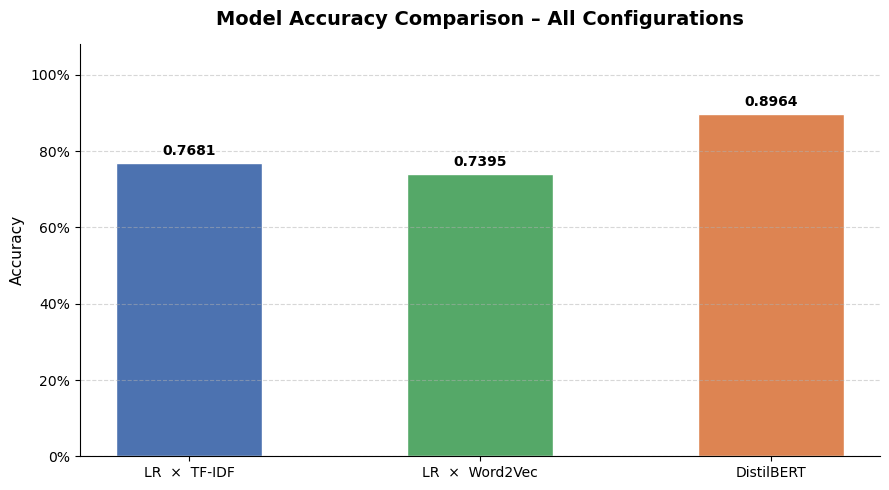

   ✅  Saved: models/viz_accuracy_comparison.png


In [27]:
# ── 4.2  Model Accuracy Comparison Bar Chart ──
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#4C72B0', '#55A868', '#DD8452']   # blue=LR×TF-IDF, green=LR×W2V, orange=DistilBERT
bars = ax.bar(results_df.index, results_df['Accuracy'], color=colors, edgecolor='white', width=0.5)
ax.bar_label(bars, fmt='%.4f', padding=4, fontsize=10, fontweight='bold')
ax.set_title('Model Accuracy Comparison – All Configurations', fontsize=14, fontweight='bold', pad=14)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_ylim(0, 1.08)
ax.set_xticklabels(results_df.index, fontsize=10)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine()
plt.tight_layout()
plt.savefig('models/viz_accuracy_comparison.png', dpi=150)
plt.show()
print("   ✅  Saved: models/viz_accuracy_comparison.png")


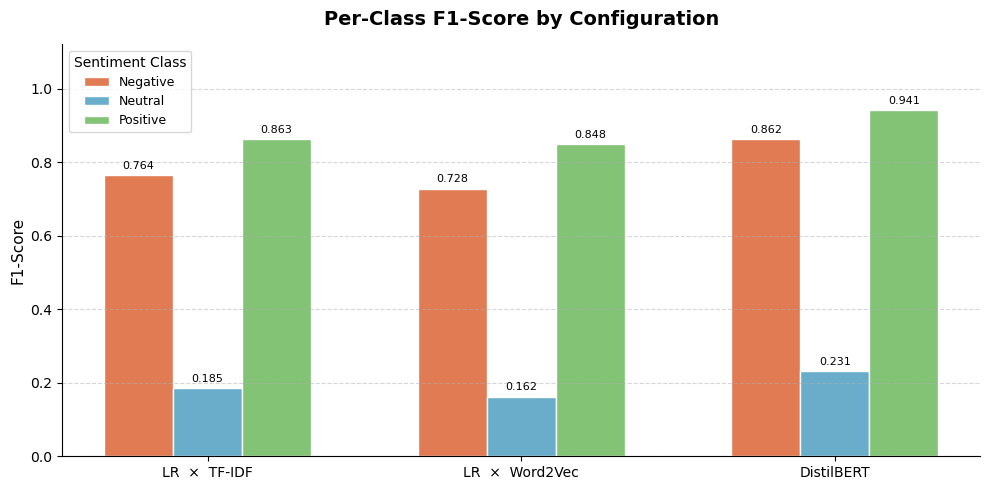

   ✅  Saved: models/viz_f1_per_class.png


In [28]:
# ── 4.3  Per-Class F1-Score Grouped Bar Chart ─
f1_data = {}
for name, (y_pred, _) in configs.items():
    report = classification_report(y_test, y_pred, target_names=CLASS_NAMES, output_dict=True)
    f1_data[name] = {cls: report[cls]['f1-score'] for cls in CLASS_NAMES}

f1_df = pd.DataFrame(f1_data).T   # rows = configs, cols = classes

fig, ax = plt.subplots(figsize=(10, 5))
x      = np.arange(len(f1_df))
width  = 0.22
pal    = ['#E07B54', '#6AADCB', '#82C375']

for i, cls in enumerate(CLASS_NAMES):
    rects = ax.bar(x + i * width, f1_df[cls], width, label=cls, color=pal[i], edgecolor='white')
    ax.bar_label(rects, fmt='%.3f', padding=3, fontsize=8)

ax.set_title('Per-Class F1-Score by Configuration', fontsize=14, fontweight='bold', pad=14)
ax.set_ylabel('F1-Score', fontsize=11)
ax.set_xticks(x + width)
ax.set_xticklabels(f1_df.index, fontsize=10)
ax.set_ylim(0, 1.12)
ax.legend(title='Sentiment Class', fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine()
plt.tight_layout()
plt.savefig('models/viz_f1_per_class.png', dpi=150)
plt.show()
print("   ✅  Saved: models/viz_f1_per_class.png")


In [ ]:
# ── 4.4  Confusion Matrices (1×3 grid) ────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()

for idx, (name, (y_pred, _)) in enumerate(configs.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        ax=axes[idx], linewidths=0.5, linecolor='white',
        annot_kws={'size': 11}
    )
    acc = accuracy_score(y_test, y_pred)
    axes[idx].set_title(f'{name}\nAccuracy = {acc:.4f}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Predicted Label', fontsize=9)
    axes[idx].set_ylabel('True Label', fontsize=9)

plt.suptitle('Confusion Matrices – All Configurations', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('models/viz_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("   ✅  Saved: models/viz_confusion_matrices.png")


In [ ]:
# ── 4.5  ROC Curves (One-vs-Rest, macro-average) ──
# Binarize labels for multi-class ROC
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()
line_colors = ['#2196F3', '#FF5722', '#4CAF50']

for idx, (name, (_, y_proba)) in enumerate(configs.items()):
    ax = axes[idx]
    mean_fpr = np.linspace(0, 1, 200)
    tprs, aucs_list = [], []

    for i, cls in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        interp_tpr  = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
        roc_auc = auc(fpr, tpr)
        aucs_list.append(roc_auc)
        ax.plot(fpr, tpr, color=line_colors[i], lw=1.5,
                label=f'{cls}  (AUC = {roc_auc:.3f})')

    mean_tpr     = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc     = auc(mean_fpr, mean_tpr)
    ax.plot(mean_fpr, mean_tpr, color='black', lw=2.2, linestyle='--',
            label=f'Macro-avg (AUC = {mean_auc:.3f})')
    ax.plot([0, 1], [0, 1], 'k:', lw=1, alpha=0.5)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_title(f'ROC Curve – {name}', fontsize=11, fontweight='bold')
    ax.set_xlabel('False Positive Rate', fontsize=9)
    ax.set_ylabel('True Positive Rate', fontsize=9)
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(linestyle='--', alpha=0.4)

plt.suptitle('ROC Curves (One-vs-Rest) – All Configurations', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('models/viz_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("   ✅  Saved: models/viz_roc_curves.png")


In [ ]:
# ─────────────────────────────────────────────
# SECTION 5 │ AUTO-SAVE BEST MODEL BY F1-MACRO
# ─────────────────────────────────────────────

print("\n" + "="*60)
print("  SECTION 5 │ SAVING BEST MODEL")
print("="*60)

best_config = results_df['F1-Macro'].idxmax()
best_f1     = results_df.loc[best_config, 'F1-Macro']
print(f"\n🏆  Best configuration : {best_config}")
print(f"    F1-Macro score      : {best_f1:.4f}")

# Map config name → fitted model object + feature set label
# (fixed: variable names now match those assigned in training cells)
model_map = {
    'LR  ×  TF-IDF'   : (best_lr_tfidf, 'tfidf'),
    'LR  ×  Word2Vec' : (best_lr_w2v,   'w2v'),
    'DistilBERT'      : (bert_model,     'bert'),
}

best_model, best_feature = model_map[best_config]

# Save model
if best_feature == 'bert':
    best_model.save_pretrained('models/best_model_bert')
    tokenizer_bert.save_pretrained('models/best_model_bert')
    print("   ✅  Saved: models/best_model_bert/  (DistilBERT model + tokenizer)")
else:
    joblib.dump(best_model, 'models/best_model.pkl')
    print("   ✅  Saved: models/best_model.pkl")

# Save the corresponding vectorizer (only for sklearn models)
if best_feature == 'tfidf':
    joblib.dump(tfidf_vectorizer, 'models/best_vectorizer.pkl')
    print("   ✅  Saved: models/best_vectorizer.pkl  (TF-IDF vectorizer)")
elif best_feature == 'w2v':
    w2v_model.save('models/best_w2v_model.bin')
    print("   ✅  Saved: models/best_w2v_model.bin   (Word2Vec model)")
else:
    print("   ℹ️   DistilBERT is self-contained — no separate vectorizer needed.")

# Save the results comparison table as CSV for the report
results_df.to_csv('models/model_comparison_results.csv')
print("   ✅  Saved: models/model_comparison_results.csv")

# Save feature type label so downstream apps know which model to load
with open('models/best_feature_type.txt', 'w') as f:
    f.write(best_feature)
print(f"   ✅  Saved: models/best_feature_type.txt  (value = '{best_feature}')")

print("\n🎉  Model selection & training phase complete!")
if best_feature == 'bert':
    print("    Load DistilBERT with: DistilBertForSequenceClassification.from_pretrained('models/best_model_bert')")
else:
    print("    Load in Streamlit with: joblib.load('models/best_model.pkl')")
